# **Introduction & Problem Identification**
In this project, we will be analyzing data from a company to find which department has the lowest job satisfaction. We will research how satisfied employees are with their job and see if their are any correlations between their satisfaction and other factors such as salary, productivity, and the department they work in. Once we discover what variables lead to low job satisfaction, we will develop insights and solutions to raising job satisfaction for that department.

Dataset link: [Employee Productivity and Satisfaction HR Data](https://www.kaggle.com/datasets/adityaab1407/employee-productivity-and-satisfaction-hr-data/data)

# **Importing our dataset**
We will be inputting a dataset containing information for the company. This dataset was obtained from Kaggle.com. We will be working with this dataset for this project.

In [161]:
import pandas as pd

In [162]:
df = pd.read_csv('/content/hr_dashboard_data.csv')

# **Verifying the Data**
We will display samples and information of the data to see if it works properly.

In [163]:
#shows the first 5 rows of the dataset
df.head(5)

,Name,Age,Gender,Projects Completed,Productivity (%),Satisfaction Rate (%),Feedback Score,Department,Position,Joining Date,Salary
0,Douglas Lindsey,25,Male,11,57,25,4.7,Marketing,Analyst,Jan-20,63596
1,Anthony Roberson,59,Female,19,55,76,2.8,IT,Manager,Jan-99,112540
2,Thomas Miller,30,Male,8,87,10,2.4,IT,Analyst,Jan-17,66292
3,Joshua Lewis,26,Female,1,53,4,1.4,Marketing,Intern,Jan-22,38303
4,Stephanie Bailey,43,Male,14,3,9,4.5,IT,Team Lead,Jan-05,101133


In [164]:
#states the data type for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   200 non-null    object 
 1   Age                    200 non-null    int64  
 2   Gender                 200 non-null    object 
 3   Projects Completed     200 non-null    int64  
 4   Productivity (%)       200 non-null    int64  
 5   Satisfaction Rate (%)  200 non-null    int64  
 6   Feedback Score         200 non-null    float64
 7   Department             200 non-null    object 
 8   Position               200 non-null    object 
 9   Joining Date           200 non-null    object 
 10  Salary                 200 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 17.3+ KB


In [165]:
df.describe()

,Age,Projects Completed,Productivity (%),Satisfaction Rate (%),Feedback Score,Salary
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,34.650000,11.455000,46.755000,49.935000,2.883000,76619.245000
std,9.797318,6.408849,28.530068,28.934353,1.123263,27082.299202
min,22.000000,0.000000,0.000000,0.000000,1.000000,30231.000000
25%,26.000000,6.000000,23.000000,25.750000,1.900000,53080.500000
50%,32.000000,11.000000,45.000000,50.500000,2.800000,80540.000000
75%,41.000000,17.000000,70.000000,75.250000,3.900000,101108.250000
max,60.000000,25.000000,98.000000,100.000000,4.900000,119895.000000


**NOTE:** When using **df.describe()**, we use the opportunity to spot any errors and inconsistencies in the dataset. Examples include extreme values, missing values, and values that don't make sense; These values include numbers that go far above or below there range such as negative numbers. For this particular case, there aren't any extreme or incorrect values; All of the data looks reasonable to work with.

But for the sake of this project, let's filter the dataset where we have values above 0 and drop unnecessary columns.

In [166]:
#Filtering the dataset to have values above 0
df = df[(df['Projects Completed'] > 0) & (df['Productivity (%)'] > 0) & (df['Satisfaction Rate (%)'] > 0)]

In [167]:
df.drop(columns=['Name', 'Age', 'Joining Date'], inplace=True)

In [168]:
df.head()

,Gender,Projects Completed,Productivity (%),Satisfaction Rate (%),Feedback Score,Department,Position,Salary
0,Male,11,57,25,4.7,Marketing,Analyst,63596
1,Female,19,55,76,2.8,IT,Manager,112540
2,Male,8,87,10,2.4,IT,Analyst,66292
3,Female,1,53,4,1.4,Marketing,Intern,38303
4,Male,14,3,9,4.5,IT,Team Lead,101133


In [169]:
#checking for null values
df.isnull().sum()

,0
Gender,0
Projects Completed,0
Productivity (%),0
Satisfaction Rate (%),0
Feedback Score,0
Department,0
Position,0
Salary,0


**NOTE:** When cleaning a dataset, we check for any null values that will reduce accuracy in our visualizations. Since there are no null values in this dataset, we can move on.

# **Data Visualization**


In the following sections, we will use data visualizations to understand employee satisfaction across the whole company. We want to know the average satisfaction for each department is and see what contributes to their satisfaction.

### **Box and Whiskers Plot Visualization**

In this section, we will use Box Plots to discover employee satisfaction across the company. The reason we are choosing to use a box plot is because it allows us to see how employee satisfaction differs among departments. First, we will make a box plot to discover the average employee rating across all of the departments.

In [170]:
# importing necessary libraries for making data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

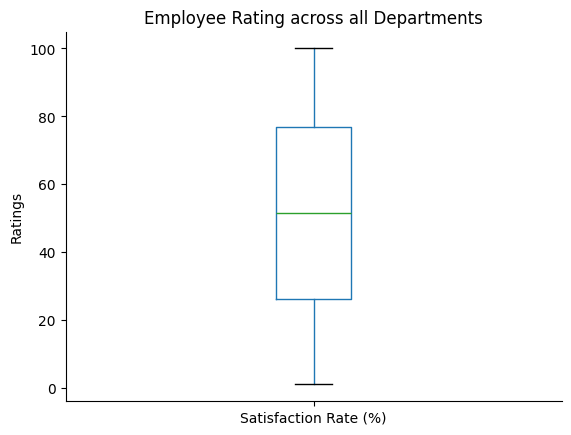

In [171]:
df.boxplot(column='Satisfaction Rate (%)', grid=False)
# green represents median

plt.title('Employee Rating across all Departments')
plt.ylabel('Ratings')

sns.despine()

In [172]:
q1 = df['Satisfaction Rate (%)'].quantile(0.25)
median = df['Satisfaction Rate (%)'].quantile(0.50) # This is the median (Q2)
q3 = df['Satisfaction Rate (%)'].quantile(0.75)
mean = df['Satisfaction Rate (%)'].mean()

print(f'Q1: {q1}')
print(f'Median: {median}')
print(f'Q3: {q3}')
print(f'Mean: {mean}')

Q1: 26.25
Median: 51.5
Q3: 76.75
Mean: 51.05789473684211


#### **Insights:**
Based on the Box and Whiskers visualization, we can observe that...


*   The upper quartile is 76.75.
*   The lower quartile is around 26.25.
*   The mean is 51.06.
*   There are no outliers.

Now that we know what the average employee satisfaction rate is across all departments, we want to know how the satisfaction rate differs for each department.

/tmp/ipykernel_925/3500265171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Department', y='Satisfaction Rate (%)', notch=True, palette='tab10')


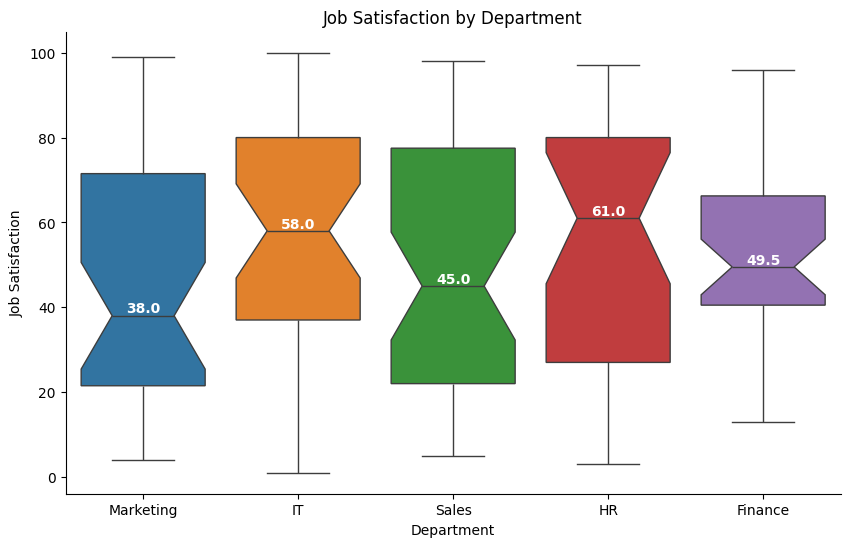

In [173]:
# Running visualization for average job satisfaction by department
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='Department', y='Satisfaction Rate (%)', notch=True, palette='tab10')

# Calculate and annotate median values
lines = ax.get_lines()
categories = ax.get_xticks()

# In a boxplot, the median is typically the 4th line in every group of 6 lines
for i in range(len(categories)):
    # The median line for the i-th box
    median_line = lines[4 + i * 6]
    x_coord = median_line.get_xdata().mean()
    y_coord = median_line.get_ydata().mean()

    # Add text label
    ax.text(x_coord, y_coord, f'{y_coord:.1f}',
            ha='center', va='bottom', fontweight='bold', color='white')

plt.title('Job Satisfaction by Department')
plt.xlabel('Department')
plt.ylabel('Job Satisfaction')

# Clean up final result
sns.despine()

#### **Insights:**
Based on the box plot, we can observe that...


*   Marketing has the lowest median, median value, and lower quartile employee satisfaction.
*   IT and HR have the highest upper quartile employee satisfaction.



### **Histogram**

To further understand how employee satisfaction varies across departments. We will use a histogram to see how satisfaction is distributed in each department.

### **Sales Histogram**

In [174]:
sales = df[df['Department'] == 'Sales']['Satisfaction Rate (%)']

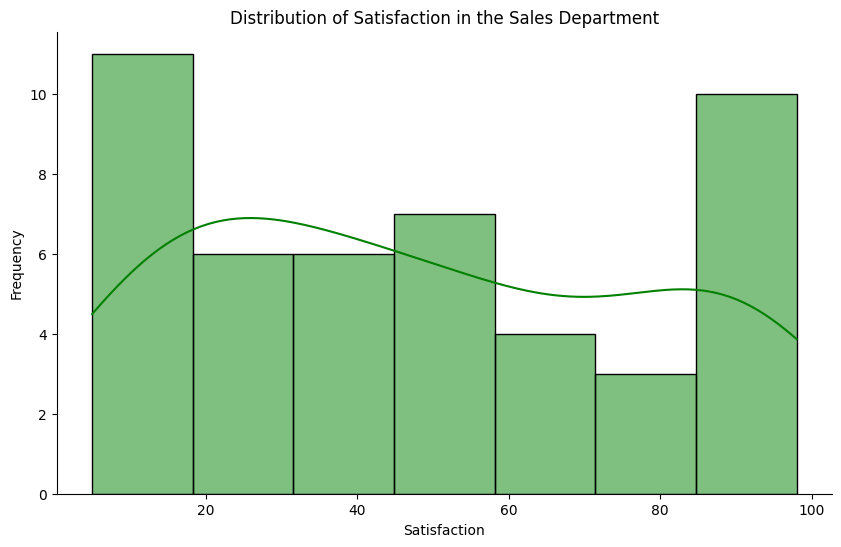

In [175]:
# Running visualization for sales histogram
plt.figure(figsize=(10, 6))
sns.histplot(sales, color='green', kde=True)

plt.title('Distribution of Satisfaction in the Sales Department')
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
# Clean up final result
sns.despine()

#### **Insights:**
Based on the histogram for sales satisfaction, we can observe that...


*   It has a positive skewness overall, but has a negative skewness level torwards the end. This could mean that most employees have low satisfaction levels, but a very large amount have high satisfaction levels.

### **Marketing Histogram**

In [176]:
marketing = df[df['Department'] == 'Marketing']['Satisfaction Rate (%)']

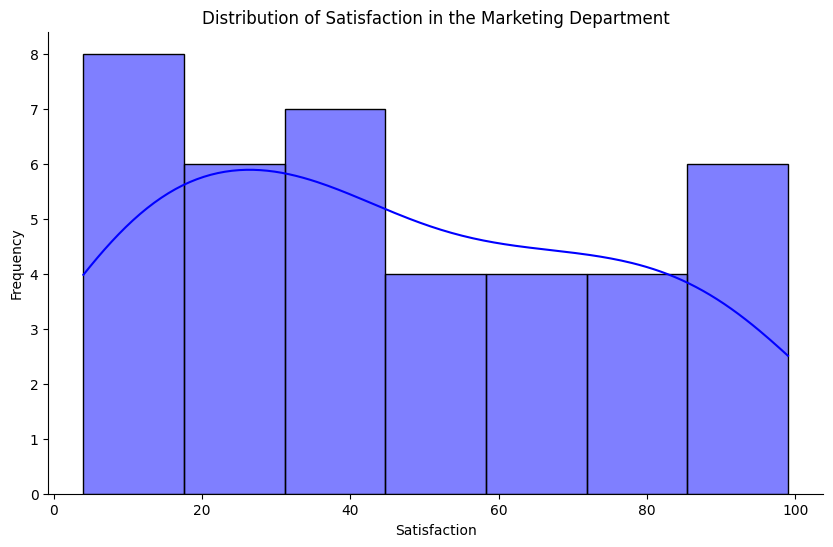

In [177]:
# Running visualization for marketing histogram
plt.figure(figsize=(10, 6))
sns.histplot(marketing, color='blue', kde=True)

plt.title('Distribution of Satisfaction in the Marketing Department')
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
# Clean up final result
sns.despine()

#### **Insights:**
Based on the histogram for marketing satisfaction, we can observe that...


*   It has a positive skewness meaning most employees have lower satisfaction levels, but a small amount have higher satisfaction levels..

### **Finance Histogram**

In [178]:
finance = df[df['Department'] == 'Finance']['Satisfaction Rate (%)']

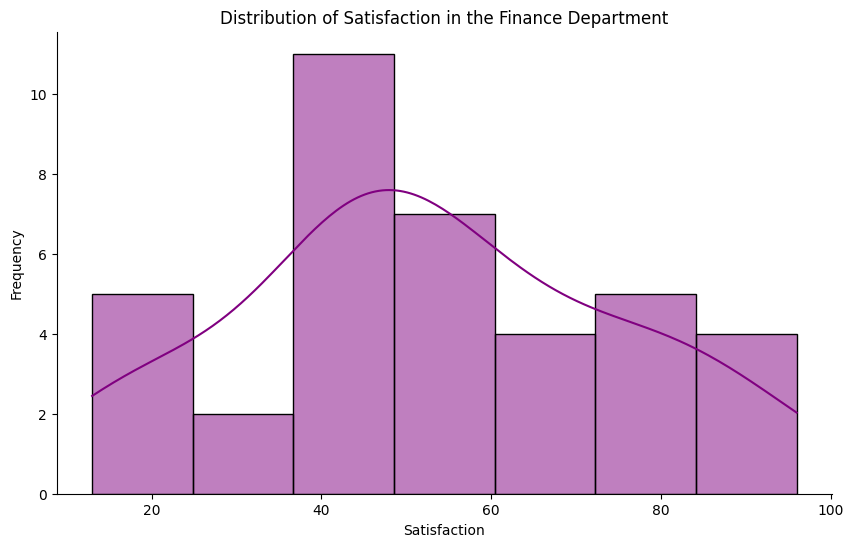

In [179]:
# Running visualization for finance histogram
plt.figure(figsize=(10, 6))
sns.histplot(finance, color='purple', kde=True)

plt.title('Distribution of Satisfaction in the Finance Department')
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
# Clean up final result
sns.despine()

#### **Insights:**
Based on the histogram for finance satisfaction, we can observe that...


*   It has a normal distribution. This means that most employees satisfaction levels are around the average.
*   It has a high kurtosis meaning there morer extreme values.

### **IT Histogram**

In [180]:
it = df[df['Department'] == 'IT']['Satisfaction Rate (%)']

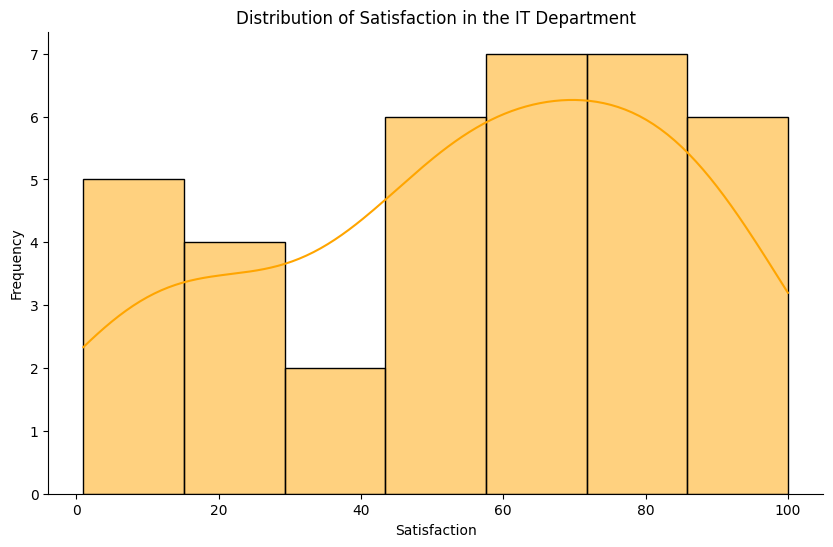

In [181]:
# Running visualization for it histogram
plt.figure(figsize=(10, 6))
sns.histplot(it, color='orange', kde=True)

plt.title('Distribution of Satisfaction in the IT Department')
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
# Clean up final result
sns.despine()

#### **Insights:**
Based on the histogram for it satisfaction, we can observe that...


*   It has a negative skewness overall. This means that most employees have higher satisfaction levels, but a few have lower satisfaction levels.

### **HR Histogram**

In [182]:
hr = df[df['Department'] == 'HR']['Satisfaction Rate (%)']

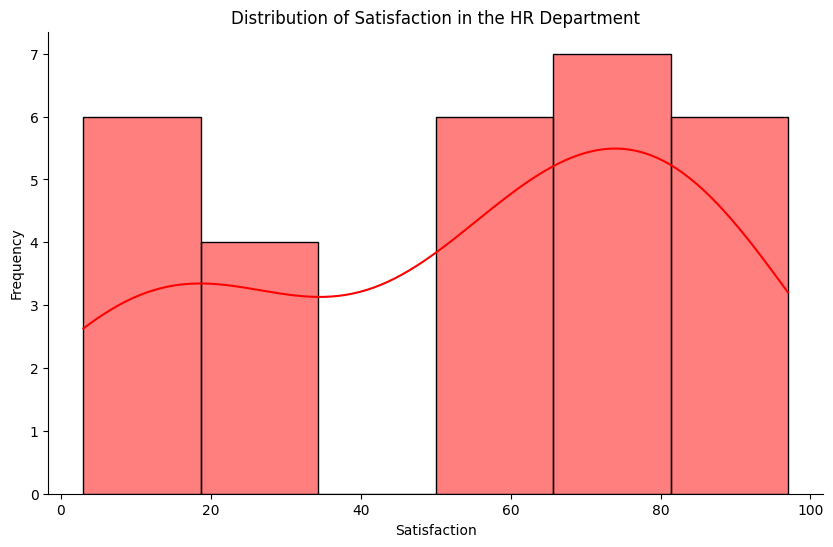

In [183]:
# Running visualization for hr histogram
plt.figure(figsize=(10, 6))
sns.histplot(hr, color='red', kde=True)

plt.title('Distribution of Satisfaction in the HR Department')
plt.xlabel('Satisfaction')
plt.ylabel('Frequency')
# Clean up final result
sns.despine()

#### **Insights:**
Based on the histogram for hr satisfaction, we can observe that...


*   It has a slight positive skew in the beginning, then becomes more negative. This means that most employees have higher satisfaction levels, but a large amount have lower satisfaction levels.

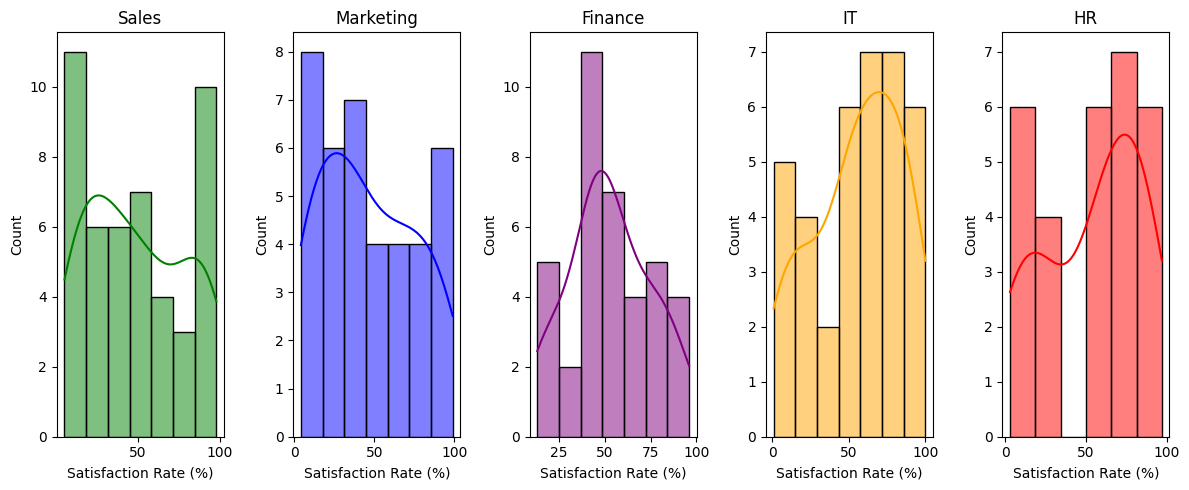

In [184]:
#displaying all histograms side by side
fig, axes = plt.subplots(1, 5, figsize=(12, 5))

sns.histplot(sales, color='green', kde=True, ax=axes[0])
axes[0].set_title('Sales')

sns.histplot(marketing, color='blue', kde=True, ax=axes[1])
axes[1].set_title('Marketing')

sns.histplot(finance, color='purple', kde=True, ax=axes[2])
axes[2].set_title('Finance')

sns.histplot(it, color='orange', kde=True, ax=axes[3])
axes[3].set_title('IT')

sns.histplot(hr, color='red', kde=True, ax=axes[4])
axes[4].set_title('HR')

plt.tight_layout()
plt.show()

### **Which Department has the lowest job satisfaction?**
Out of all of the departments, Marketing has the lowest job satisfaction due to it having the largest positive skew on its histogram chart. This means there are overall more employees unsatisfied with their jobs. For the rest of this project, we will be focusing on the Marketing departmetn to determine how we can improve employee job satisfaction.

### **Bar Chart**

We will use a bar chart to view job satisfaction based on position and gender in the Marketing department.

<Figure size 1000x600 with 0 Axes>

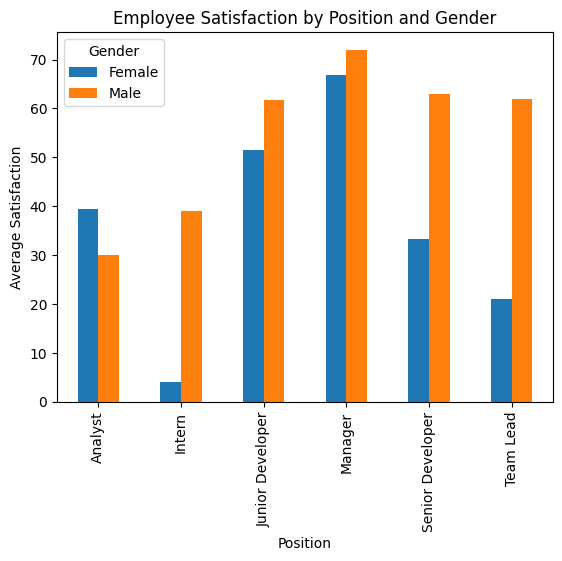

In [185]:
# Running visualization for satisfaction based on gender and position in the Marketing department.
marketing = df[df['Department'] == 'Marketing']
marketingBar = marketing.groupby(['Position', 'Gender'])['Satisfaction Rate (%)'].mean().unstack()
plt.figure(figsize=(10, 6))

marketingBar.plot(kind='bar')
plt.title('Employee Satisfaction by Position and Gender')
plt.xlabel('Position')
plt.ylabel('Average Satisfaction')
plt.show()

#### **Insights:**
Based on the bar chart, we can oberve that that women are overall less satisfied with their job than their male coworkers. Furthermore, the biggest gaps with women are...

* Intern
* Senior Developer
* Team Lead


Let's dig deeper to see what causes job dissatisfaction for them.

**NOTE:** While making this project, I wanted to explore each position separately to notice any unique patterns for that position. I wanted to do this to see if the different positions had different causes for low job satisfaction. However, the initial size of the dataset had only 200 entries. With all the filtering we've done so far by narrowing it down the three positions in the Marketing department, we would have very small data samples. This can lead to many problems such as overfitting, lack of generalization, and sensitivity to outliers. So for the sake of this project, we will combine all three positions together.

In [186]:
#combining all three positions together
marketingWom = df[
    (df['Department'] == 'Marketing') &
    (df['Gender'] == 'Female') &
    (df['Position'].isin(['Intern', 'Team Lead', 'Senior Developer']))
]

### **Marketing Regression Plots**

In this section, we will use a regression plots to see if we can discover if there are any correlations with satisfaction rate and other variables in the Marketing department.

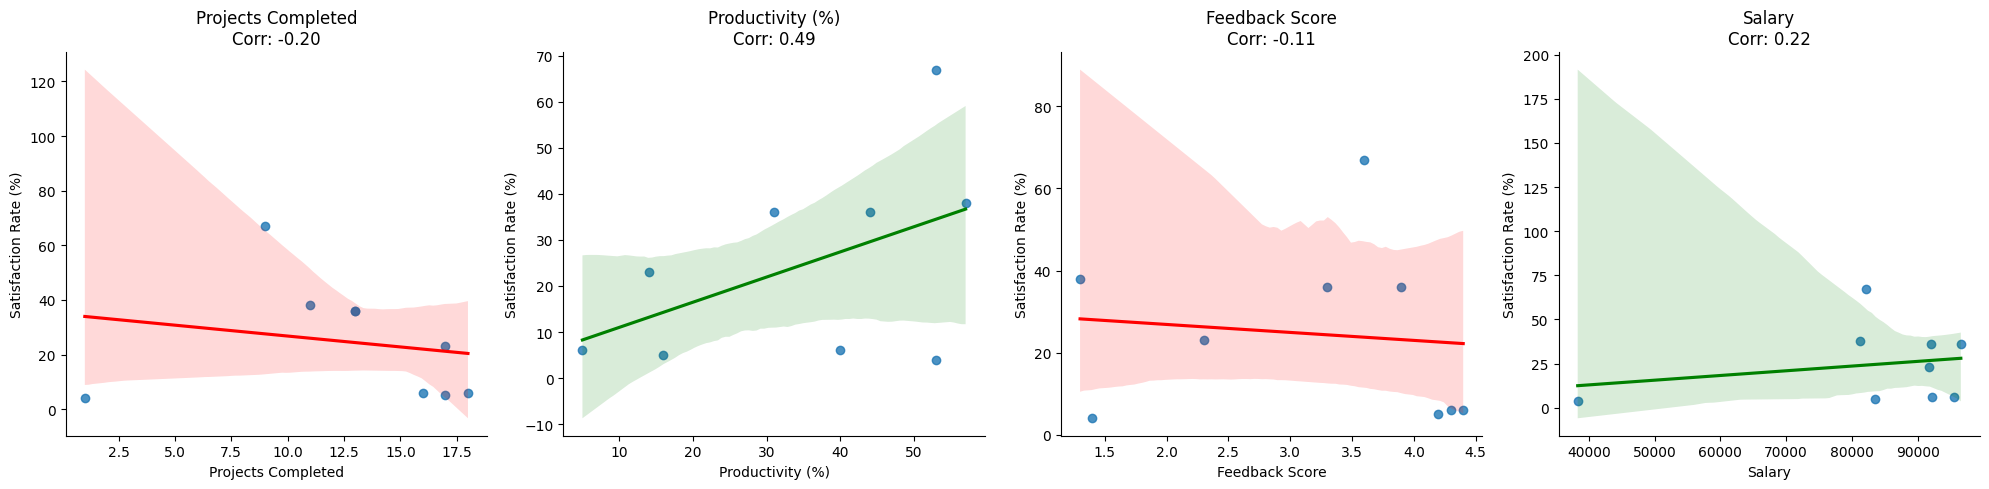

In [187]:
x_vars = ['Projects Completed', 'Productivity (%)', 'Feedback Score', 'Salary']
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for i, var in enumerate(x_vars):
    # Calculate the correlation result
    correlation = marketingWom['Satisfaction Rate (%)'].corr(marketingWom[var])

    # Logic: Green for positive, Red for negative
    current_color = 'green' if correlation > 0 else 'red'

    sns.regplot(ax=axes[i],
                data=marketingWom,
                x=var,
                y='Satisfaction Rate (%)',
                line_kws={'color': current_color})

    axes[i].set_title(f'{var}\nCorr: {correlation:.2f}')

plt.tight_layout()
sns.despine()
plt.show()

#### **Insights:**
In the regression plots for the female employees...
* The satisfaction rate has a positive relationship with productivity and salary. This means the more productive the employee is, the more satisifed they are; And the higher their salary, the higher the satisfaction rate.
* The satisfaction rate has a negative relationship with projects completed and feedback score. This means the more projects completed, the lower the satisfaction rate; And the lower the feedback score, the lower the satisfaction rate.

For comparison, let's see how male satisfaction rates differ in these same roles for Marketing.

In [188]:
marketingMen = df[
    (df['Department'] == 'Marketing') &
    (df['Gender'] == 'Male') &
    (df['Position'].isin(['Intern', 'Team Lead', 'Senior Developer']))
]

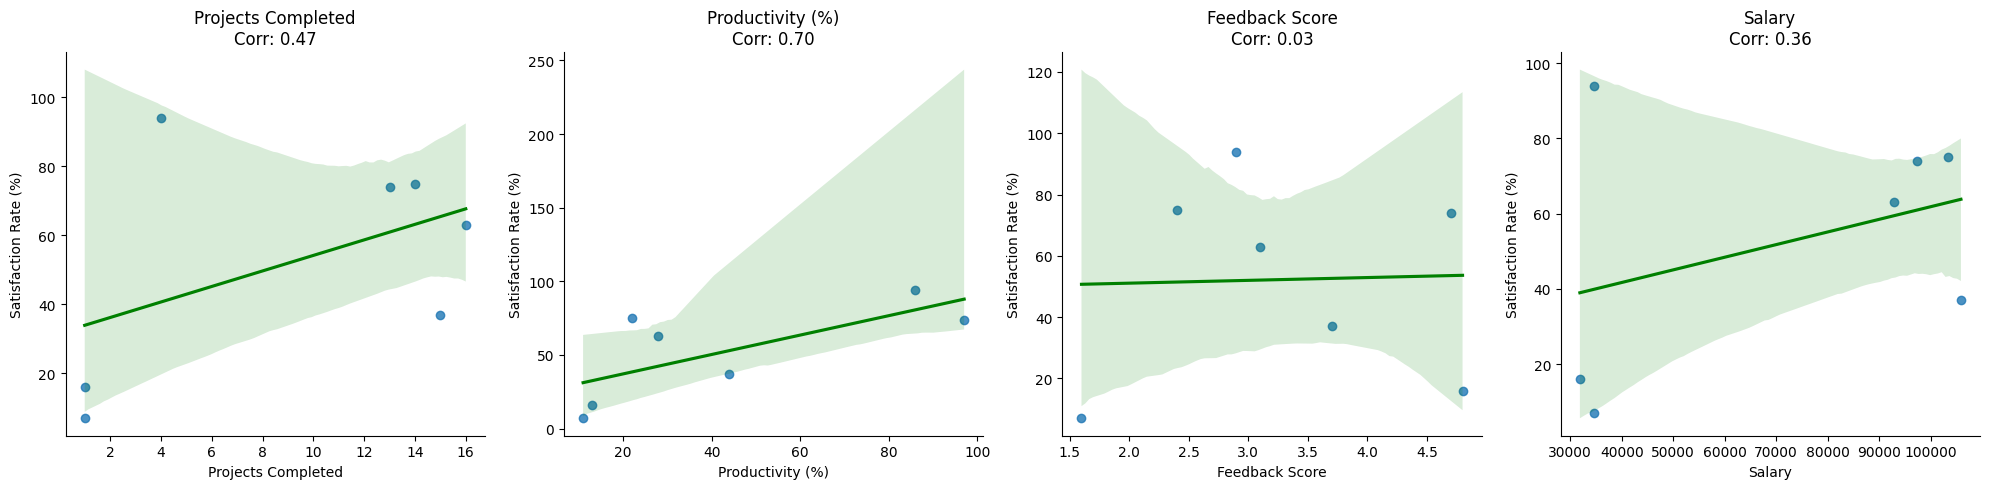

In [189]:
x_vars = ['Projects Completed', 'Productivity (%)', 'Feedback Score', 'Salary']
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for i, var in enumerate(x_vars):
    # Calculate the correlation result
    correlation = marketingMen['Satisfaction Rate (%)'].corr(marketingMen[var])

    # Logic: Green for positive, Red for negative
    current_color = 'green' if correlation > 0 else 'red'

    sns.regplot(ax=axes[i],
                data=marketingMen,
                x=var,
                y='Satisfaction Rate (%)',
                line_kws={'color': current_color})

    axes[i].set_title(f'{var}\nCorr: {correlation:.2f}')

plt.tight_layout()
sns.despine()
plt.show()

#### **Insights:**
All of the regression plots display positive relations with satisfaction rate. This means that...
* The more projects completed, the higher the satisfaction rate.
* The higher the productivity, the higher the satisfaction rate.
* The higher the feedback score, the higher the satisfaction rate. However, the correlation score shows that it's a very weak relation.
* The higher the salary, the higher the satisfaction rate.

# **Conclusion and Findings**







In this project, we analyzed data to discover which department had the lowest employee satisfaction. After seeing where satisfaction was distributed for each department, we discovered that marketing had the lowest job satisfaction rates. It was at this point where we focused entirely on the marketing department. Digging deeper into analyzing the marketing department, we discovered that female employees were overwhelmingly less satisfied in the intern, team lead, and senior developer roles than their male coworkers. Due to the small size of our data sample at this point, we combined the data together for a satisfactory data sample. Afterwards, we used regression plots to see how satisfaction rates correlate with other variables. With these regression plots, we noticed that projects completed and feedback scores were negative for women and positive for men.

Based on the results, we can determine that the leading causes for low satisfaction rates in the intern, team lead, and senior developer roles are based on projects completed and feedback scores. The regression plots show that the more projects a female employee completes, the less satisfied their job satisfaction is. In addition, there job satisfaction decreases as their feedback scores get lower. Possible reasons for this could be employees suffering from burnout and issues with bias from management. Recommendations to improving job satisfaction for these employees are to assign a reasonable amount of projects and improving employee and manager relations.